# Importar librerias

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib
import matplotlib.pyplot as plt
import scipy
from matplotlib.pyplot import figure
import os

plt.style.use('ggplot')
# format consistency for plots
%matplotlib inline 
matplotlib.rcParams['figure.figsize'] = (12,8) # Default size of plots

# Preparación y lectura del dataset

## Lectura

In [2]:
path = os.getcwd()
directorio = os.path.join(path, 'datasets')
if not os.path.exists(directorio):
    os.makedirs(directorio)

In [3]:
mpath, directories, files = next(os.walk(directorio))
nfiles = len(files)
datasets = []

for i in range(nfiles):
    if files[i].endswith('.csv'):
        temp_df = pd.read_csv(os.path.join(directorio, files[i]))
    elif files[i].endswith('.xlsx'):
        temp_df = pd.read_excel(os.path.join(directorio, files[i]))
    else:
        print(f"Archivo no soportado: {files[i]}")
    datasets.append(temp_df)

## Asignar datasets

In [5]:
df = pd.DataFrame(datasets[1])

# Dataset específico (Para este ejercicio)

In [2]:
path = os.getcwd()
directorio = os.path.join(path, 'datasets')
archivo = os.path.join(directorio, 'movies.csv')
dataset = pd.read_csv(archivo)
df = pd.DataFrame(dataset)

# Operaciones

## Exploración del dataset

In [3]:
df.head(10)

,name,rating,genre,year,released,score,votes,director,writer,star,country,budget,gross,company,runtime
0,The Shining,R,Drama,1980,"June 13, 1980 (United States)",8.4,927000.0,Stanley Kubrick,Stephen King,Jack Nicholson,United Kingdom,19000000.0,46998772.0,Warner Bros.,146.0
1,The Blue Lagoon,R,Adventure,1980,"July 2, 1980 (United States)",5.8,65000.0,Randal Kleiser,Henry De Vere Stacpoole,Brooke Shields,United States,4500000.0,58853106.0,Columbia Pictures,104.0
2,Star Wars: Episode V - The Empire Strikes Back,PG,Action,1980,"June 20, 1980 (United States)",8.7,1200000.0,Irvin Kershner,Leigh Brackett,Mark Hamill,United States,18000000.0,538375067.0,Lucasfilm,124.0
3,Airplane!,PG,Comedy,1980,"July 2, 1980 (United States)",7.7,221000.0,Jim Abrahams,Jim Abrahams,Robert Hays,United States,3500000.0,83453539.0,Paramount Pictures,88.0
4,Caddyshack,R,Comedy,1980,"July 25, 1980 (United States)",7.3,108000.0,Harold Ramis,Brian Doyle-Murray,Chevy Chase,United States,6000000.0,39846344.0,Orion Pictures,98.0
5,Friday the 13th,R,Horror,1980,"May 9, 1980 (United States)",6.4,123000.0,Sean S. Cunningham,Victor Miller,Betsy Palmer,United States,550000.0,39754601.0,Paramount Pictures,95.0
6,The Blues Brothers,R,Action,1980,"June 20, 1980 (United States)",7.9,188000.0,John Landis,Dan Aykroyd,John Belushi,United States,27000000.0,115229890.0,Universal Pictures,133.0
7,Raging Bull,R,Biography,1980,"December 19, 1980 (United States)",8.2,330000.0,Martin Scorsese,Jake LaMotta,Robert De Niro,United States,18000000.0,23402427.0,Chartoff-Winkler Productions,129.0
8,Superman II,PG,Action,1980,"June 19, 1981 (United States)",6.8,101000.0,Richard Lester,Jerry Siegel,Gene Hackman,United States,54000000.0,108185706.0,Dovemead Films,127.0
9,The Long Riders,R,Biography,1980,"May 16, 1980 (United States)",7.0,10000.0,Walter Hill,Bill Bryden,David Carradine,United States,10000000.0,15795189.0,United Artists,100.0


## Limpieza rápida

In [4]:
# Buscar datos nulos
for col in df.columns:
    null_rate = np.mean(df[col].isnull())
    print('{}: {:.2%} nulos'.format(col, null_rate))

name: 0.00% nulos
rating: 1.00% nulos
genre: 0.00% nulos
year: 0.00% nulos
released: 0.03% nulos
score: 0.04% nulos
votes: 0.04% nulos
director: 0.00% nulos
writer: 0.04% nulos
star: 0.01% nulos
country: 0.04% nulos
budget: 28.31% nulos
gross: 2.46% nulos
company: 0.22% nulos
runtime: 0.05% nulos


In [5]:
# Cleaning null values
df['budget'] = df['budget'].fillna(0)
df['gross'] = df['gross'].fillna(0)

In [6]:
# Data types
df.dtypes

name            str
rating          str
genre           str
year          int64
released        str
score       float64
votes       float64
director        str
writer          str
star            str
country         str
budget      float64
gross       float64
company         str
runtime     float64
dtype: object

In [7]:
# change data types
df['gross'] = df['gross'].astype('int64')
df['budget'] = df['budget'].astype('int64')

In [8]:
# Fixing release date
df['year_released'] = df['released'].astype(str).str.split(',').str[1].str.split(' ').str[1]
df['year_released'] = df['year_released'].fillna(df['year'])
df['year_released'] = df['year_released'].astype('int64')

In [9]:
# Sorting by gross revenue
df = df.sort_values(by=['gross'], inplace=False, ascending=False)

In [10]:
# Drop duplicates
df['name'] = df['name'].drop_duplicates().sort_values(ascending=False)

## Plots

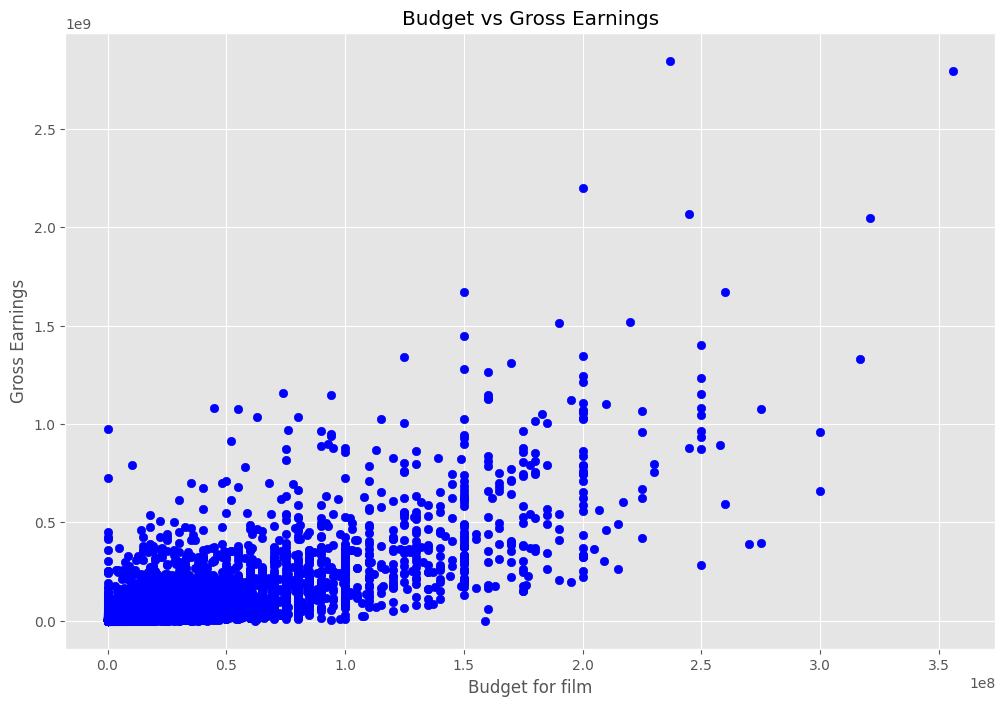

In [11]:
plt.scatter(x=df['budget'], y=df['gross'], color='blue')
plt.title('Budget vs Gross Earnings')
plt.xlabel('Budget for film')
plt.ylabel('Gross Earnings')
plt.show()

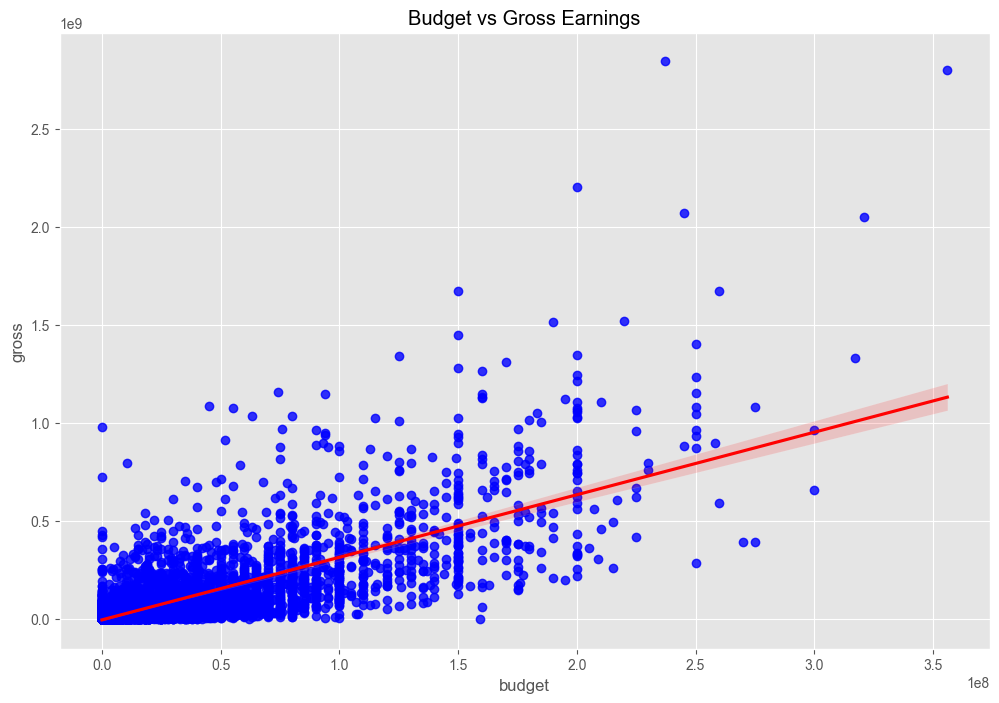

In [12]:
# Plot budget vs gross using seaborn
sns.regplot(
    data=df, 
    x='budget', 
    y='gross', 
    scatter_kws={'color': 'blue'}, 
    line_kws={'color': 'red'}
    ).set_title('Budget vs Gross Earnings')
sns.set_style('whitegrid')
sns.set_context('notebook', font_scale=1.5)


In [13]:
df.head(10)

,name,rating,genre,year,released,score,votes,director,writer,star,country,budget,gross,company,runtime,year_released
5445,Avatar,PG-13,Action,2009,"December 18, 2009 (United States)",7.8,1100000.0,James Cameron,James Cameron,Sam Worthington,United States,237000000,2847246203,Twentieth Century Fox,162.0,2009
7445,Avengers: Endgame,PG-13,Action,2019,"April 26, 2019 (United States)",8.4,903000.0,Anthony Russo,Christopher Markus,Robert Downey Jr.,United States,356000000,2797501328,Marvel Studios,181.0,2019
3045,Titanic,PG-13,Drama,1997,"December 19, 1997 (United States)",7.8,1100000.0,James Cameron,James Cameron,Leonardo DiCaprio,United States,200000000,2201647264,Twentieth Century Fox,194.0,1997
6663,Star Wars: Episode VII - The Force Awakens,PG-13,Action,2015,"December 18, 2015 (United States)",7.8,876000.0,J.J. Abrams,Lawrence Kasdan,Daisy Ridley,United States,245000000,2069521700,Lucasfilm,138.0,2015
7244,Avengers: Infinity War,PG-13,Action,2018,"April 27, 2018 (United States)",8.4,897000.0,Anthony Russo,Christopher Markus,Robert Downey Jr.,United States,321000000,2048359754,Marvel Studios,149.0,2018
7480,The Lion King,PG,Animation,2019,"July 19, 2019 (United States)",6.9,222000.0,Jon Favreau,Jeff Nathanson,Donald Glover,United States,260000000,1670727580,Walt Disney Pictures,118.0,2019
6653,Jurassic World,PG-13,Action,2015,"June 12, 2015 (United States)",7.0,593000.0,Colin Trevorrow,Rick Jaffa,Chris Pratt,United States,150000000,1670516444,Universal Pictures,124.0,2015
6043,The Avengers,PG-13,Action,2012,"May 4, 2012 (United States)",8.0,1300000.0,Joss Whedon,Joss Whedon,Robert Downey Jr.,United States,220000000,1518815515,Marvel Studios,143.0,2012
6646,Furious 7,PG-13,Action,2015,"April 3, 2015 (United States)",7.1,370000.0,James Wan,Chris Morgan,Vin Diesel,United States,190000000,1515341399,Universal Pictures,137.0,2015
7494,Frozen II,PG,Animation,2019,"November 22, 2019 (United States)",6.8,148000.0,Chris Buck,Jennifer Lee,Kristen Bell,United States,150000000,1450026933,Walt Disney Animation Studios,103.0,2019


Text(0.5, 1.0, 'Pearson Correlation Movies Dataset')

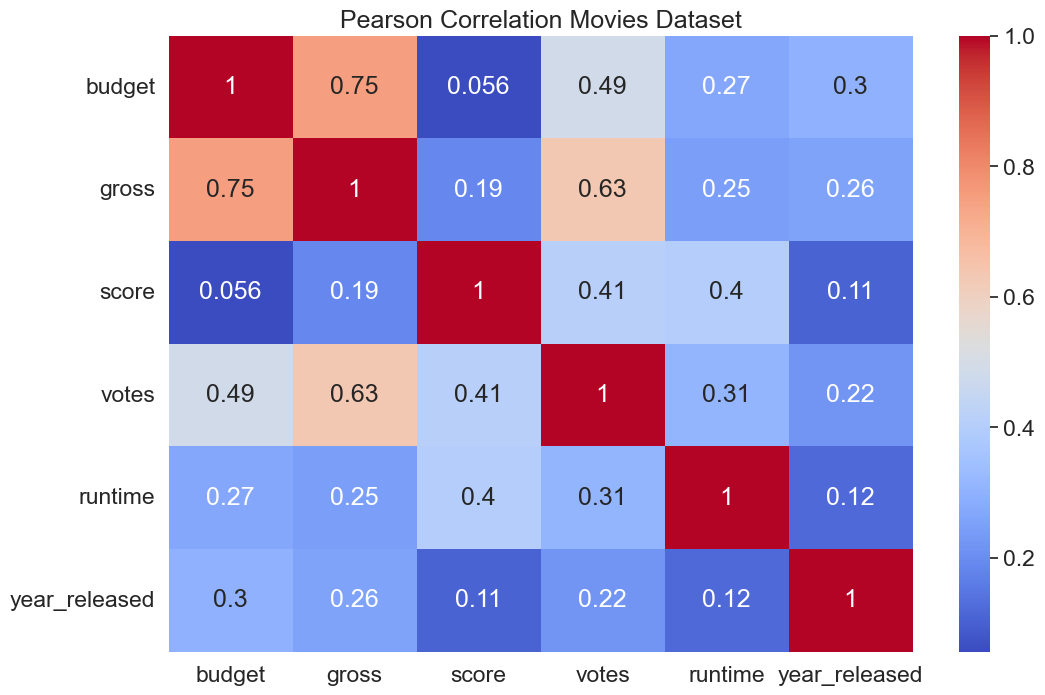

In [14]:
# def correlation matrix
variables = ['budget', 'gross', 'score', 'votes', 'runtime', 'year_released']
corr_matrix = df[variables].corr(method='spearman') # pearson, kendall, spearman
sns.heatmap(
    df[variables].corr(method='pearson'), 
    annot=True, 
    cmap='coolwarm'
    ).set_title("Pearson Correlation Movies Dataset") # overstimating correlation due to outliers

Text(0.5, 1.0, 'Kendall Correlation Movies Dataset')

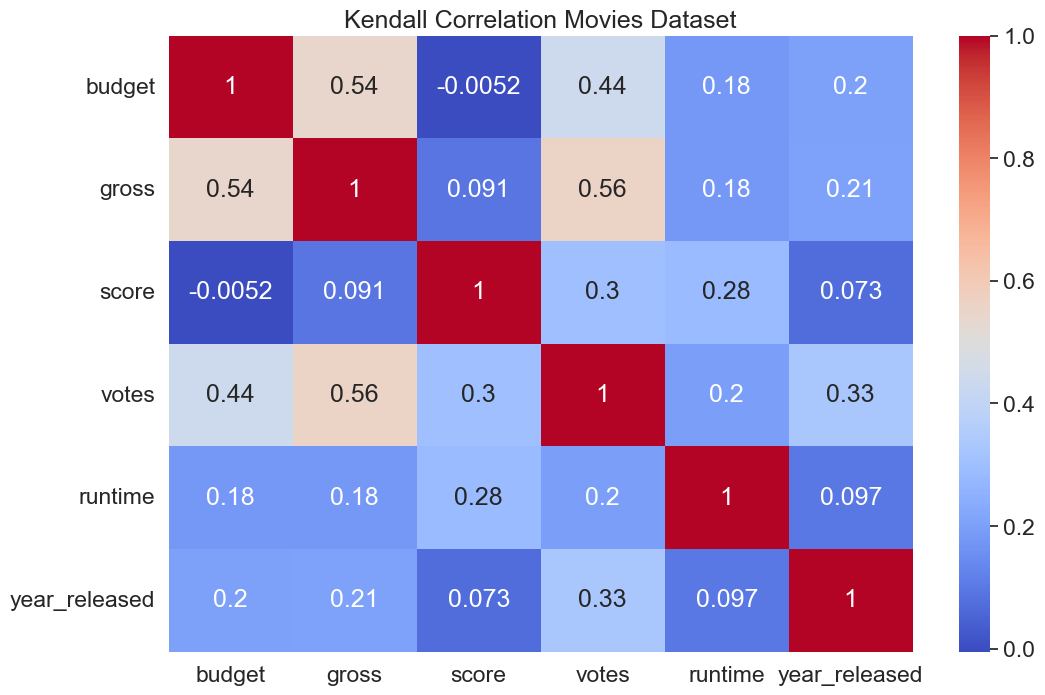

In [15]:
sns.heatmap(
    df[variables].corr(method='kendall'), 
    annot=True, 
    cmap='coolwarm'
    ).set_title("Kendall Correlation Movies Dataset") # bad assumptions about data distribution

Text(111.15624999999999, 0.5, 'Movie features')

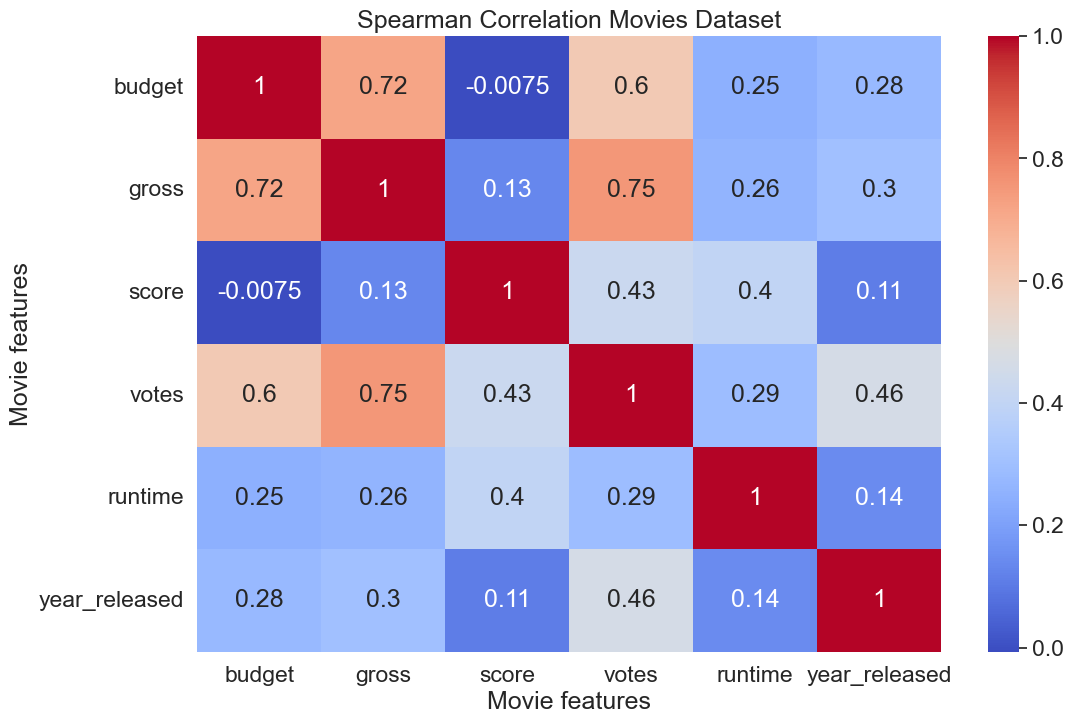

In [ ]:
sns.heatmap(
    corr_matrix, 
    annot=True, 
    cmap='coolwarm'
    ).set_title("Spearman Correlation Movies Dataset") # more robust to outliers
plt.xlabel('Movie features')
plt.ylabel('Movie features')

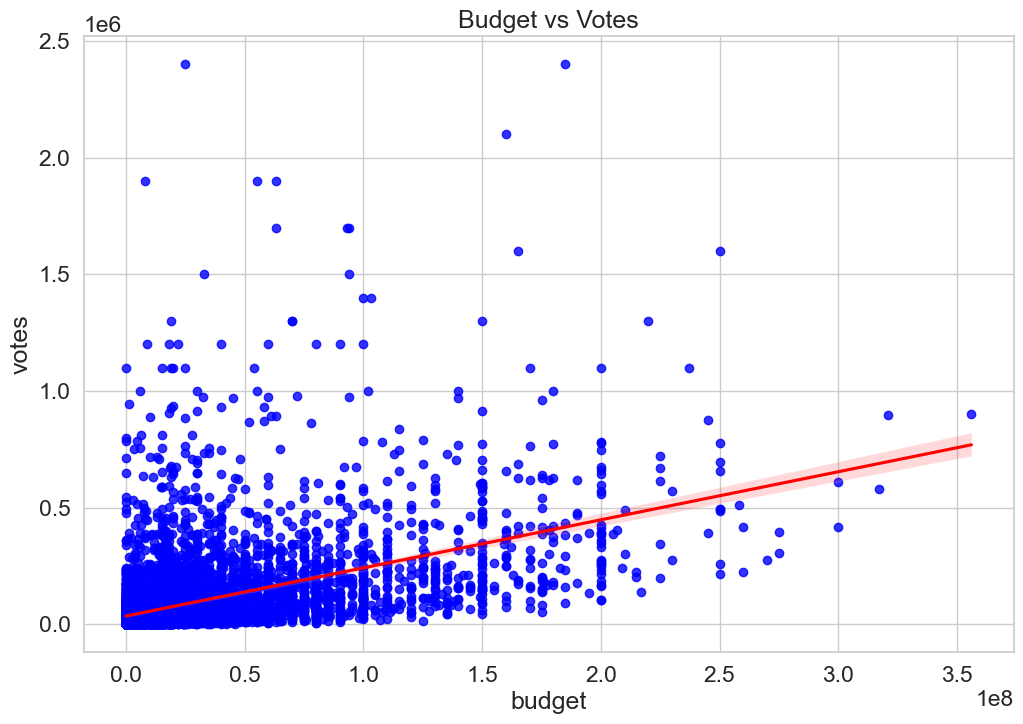

In [17]:
# Spearman tiene buen balance entre robustez a outliers y sensibilidad a relaciones no lineales, por lo que es una buena opción para analizar la correlación en este dataset.
sns.regplot(
    data=df, 
    x='budget', 
    y='votes', 
    scatter_kws={'color': 'blue'}, 
    line_kws={'color': 'red'}
    ).set_title('Budget vs Votes')
sns.set_style('whitegrid')
sns.set_context('notebook', font_scale=1.5)
# Correlation between budget and votes

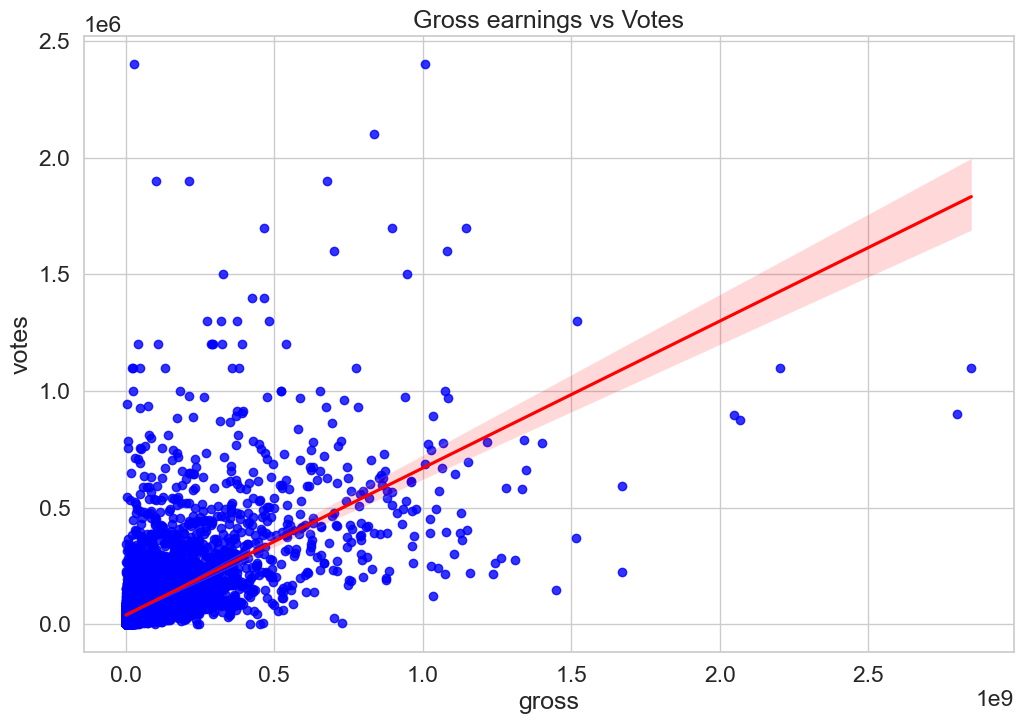

In [18]:
# Correlation between gross earnings and votes
sns.regplot(
    data=df, 
    x='gross', 
    y='votes', 
    scatter_kws={'color': 'blue'}, 
    line_kws={'color': 'red'}
    ).set_title('Gross earnings vs Votes')
sns.set_style('whitegrid')
sns.set_context('notebook', font_scale=1.5)

## Exploración

In [19]:
df['company'].head(10)

5445            Twentieth Century Fox
7445                   Marvel Studios
3045            Twentieth Century Fox
6663                        Lucasfilm
7244                   Marvel Studios
7480             Walt Disney Pictures
6653               Universal Pictures
6043                   Marvel Studios
6646               Universal Pictures
7494    Walt Disney Animation Studios
Name: company, dtype: str

In [23]:
df_num = df
for col in df_num.columns:
    if df_num[col].dtype == 'str':
        df_num[col] = df_num[col].astype('category')
        df_num[col] = df_num[col].cat.codes
df_num.head(10) # Comprobar los cambios

,name,rating,genre,year,released,score,votes,director,writer,star,country,budget,gross,company,runtime,year_released
5445,533,5,0,2009,696,7.8,1100000.0,1155,1778,2334,55,237000000,2847246203,2253,162.0,2009
7445,535,5,0,2019,183,8.4,903000.0,162,743,2241,55,356000000,2797501328,1606,181.0,2019
3045,6896,5,6,1997,704,7.8,1100000.0,1155,1778,1595,55,200000000,2201647264,2253,194.0,1997
6663,5144,5,0,2015,698,7.8,876000.0,1125,2550,524,55,245000000,2069521700,1540,138.0,2015
7244,536,5,0,2018,192,8.4,897000.0,162,743,2241,55,321000000,2048359754,1606,149.0,2018
7480,6194,4,2,2019,1488,6.9,222000.0,1455,1919,676,55,260000000,1670727580,2316,118.0,2019
6653,2969,5,0,2015,1704,7.0,593000.0,517,3568,437,55,150000000,1670516444,2281,124.0,2015
6043,5502,5,0,2012,2472,8.0,1300000.0,1517,2314,2241,55,220000000,1518815515,1606,143.0,2012
6646,2145,5,0,2015,221,7.1,370000.0,1189,706,2721,55,190000000,1515341399,2281,137.0,2015
7494,2131,4,2,2019,2676,6.8,148000.0,432,1950,1527,55,150000000,1450026933,2315,103.0,2019


Text(0.5, 1.0, 'Spearman Correlation Movies Dataset')

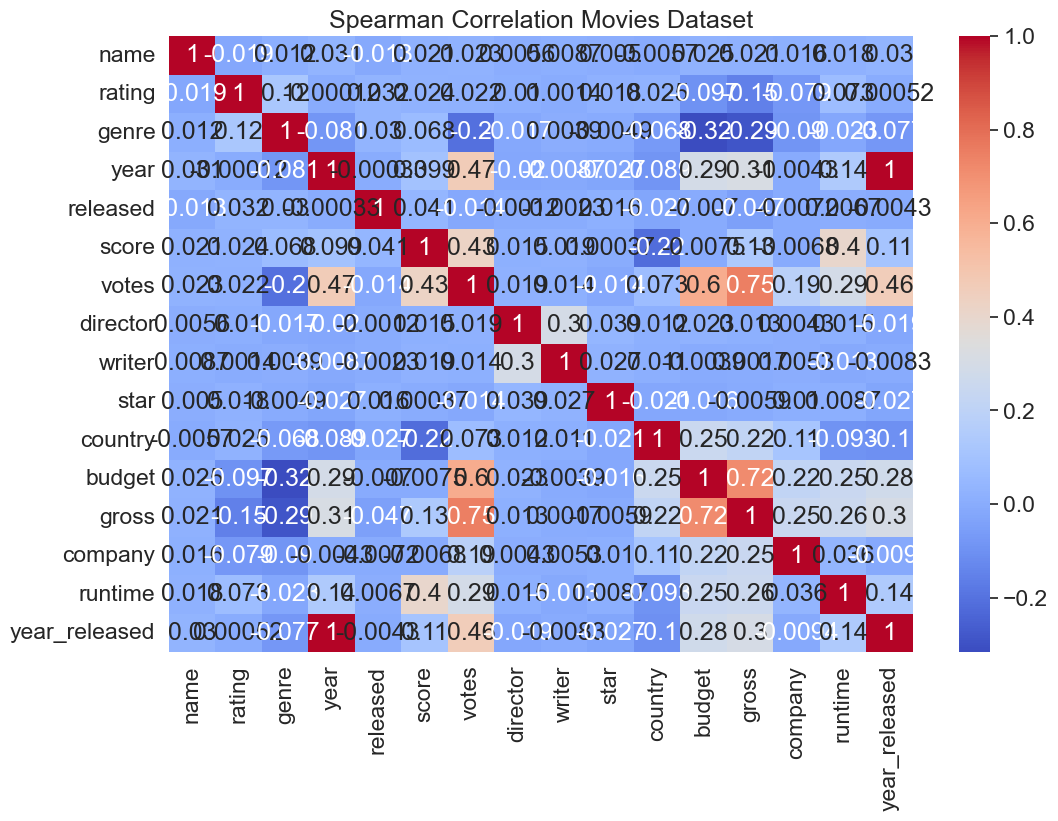

In [ ]:
corr_matrix_num = df_num.corr(method='spearman') 
sns.heatmap(
    corr_matrix_num, 
    annot=True, 
    cmap='coolwarm'
    ).set_title("Spearman Correlation Movies Dataset")

In [30]:
corr_matrix_num

,name,rating,genre,year,released,score,votes,director,writer,star,country,budget,gross,company,runtime,year_released
name,1.000000,-0.018652,0.011607,0.030657,-0.012725,0.020696,0.022880,0.005592,0.008744,0.004952,-0.005724,0.024594,0.020683,0.015843,0.017718,0.029824
rating,-0.018652,1.000000,0.123670,-0.000120,0.031884,0.024234,0.022363,0.010232,0.001379,0.017564,0.025221,-0.097319,-0.153389,-0.079008,0.072508,0.000515
genre,0.011607,0.123670,1.000000,-0.081261,0.029685,0.067659,-0.204214,-0.016710,0.003902,-0.004860,-0.067968,-0.316964,-0.286896,-0.089637,-0.023203,-0.076891
year,0.030657,-0.000120,-0.081261,1.000000,-0.000334,0.099045,0.469829,-0.019843,-0.008666,-0.026876,-0.088509,0.291152,0.314681,-0.004300,0.142977,0.997612
released,-0.012725,0.031884,0.029685,-0.000334,1.000000,0.041079,-0.014314,-0.001206,-0.002330,0.015694,-0.026772,-0.006963,-0.047161,-0.007243,0.006738,-0.004287
score,0.020696,0.024234,0.067659,0.099045,0.041079,1.000000,0.428138,0.014691,0.019175,0.000372,-0.218330,-0.007500,0.132569,-0.006822,0.399857,0.107157
votes,0.022880,0.022363,-0.204214,0.469829,-0.014314,0.428138,1.000000,0.019429,0.013890,-0.013697,0.073396,0.604627,0.752265,0.185955,0.290159,0.463197
director,0.005592,0.010232,-0.016710,-0.019843,-0.001206,0.014691,0.019429,1.000000,0.299032,0.039391,0.012424,0.023166,0.012600,0.004255,0.015192,-0.019100
writer,0.008744,0.001379,0.003902,-0.008666,-0.002330,0.019175,0.013890,0.299032,1.000000,0.027368,0.011371,-0.003927,0.001654,0.005256,-0.012915,-0.008285
star,0.004952,0.017564,-0.004860,-0.026876,0.015694,0.000372,-0.013697,0.039391,0.027368,1.000000,-0.020899,-0.016325,-0.005941,0.010087,0.008661,-0.027065


In [31]:
correlation_mat = df_num.corr(method='spearman')
corr_pairs = correlation_mat.unstack()
corr_pairs

name           name             1.000000
               rating          -0.018652
               genre            0.011607
               year             0.030657
               released        -0.012725
                                  ...   
year_released  budget           0.278784
               gross            0.300665
               company         -0.009405
               runtime          0.142792
               year_released    1.000000
Length: 256, dtype: float64

In [32]:
sorted_pairs = corr_pairs.sort_values(kind='quicksort')
sorted_pairs

genre          budget          -0.316964
budget         genre           -0.316964
gross          genre           -0.286896
genre          gross           -0.286896
score          country         -0.218330
                                  ...   
star           star             1.000000
company        company          1.000000
gross          gross            1.000000
runtime        runtime          1.000000
year_released  year_released    1.000000
Length: 256, dtype: float64

In [34]:
high_corr = sorted_pairs[(sorted_pairs > 0.5) & (sorted_pairs < 0.99)]
high_corr

votes   budget    0.604627
budget  votes     0.604627
        gross     0.716816
gross   budget    0.716816
        votes     0.752265
votes   gross     0.752265
dtype: float64

In [ ]:
# Los votos obtenidos de las películas y el presupuesto tienen una alta correlación positiva, 
# lo que sugiere que las películas con presupuestos más altos tienden a recibir más votos. 
# Esto podría deberse a que las películas con mayores presupuestos suelen tener una 
# mayor promoción y distribución, lo que aumenta su visibilidad y, por ende, 
# la cantidad de votos que reciben.
